In [5]:
import pandas as pd 
import numpy as np  
from scipy.stats import chisquare, ttest_ind  
from pathlib import Path
import os 
import matplotlib.pyplot as plt 


In [ ]:
PROJECT_ROOT = Path.cwd().resolve()

print("Project root:", PROJECT_ROOT)

## Step 1 - Load Data and Run Experiment Diagnostics  
---

In [63]:
# load experiment/synthetic dataset 
 
DATA_DIR = PROJECT_ROOT / "data"

df = pd.read_csv(DATA_DIR / "synthetic/free_shipping_experiment_sessions.csv")

df.head()

,session_id,visitor_id,session_date,period,region,test_arm,conversion_multiplier,basket_multiplier,threshold_arm,free_shipping_threshold,...,order_id,units,price_per_unit,product_revenue,shipping_revenue,total_revenue,cogs,shipping_cost,contribution_margin,qualified_for_free_shipping
0,1,650921,2025-01-01,pre,West,t65,1.306001,1.076006,pre,50.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,373732,2025-01-01,pre,West,t65,0.988317,1.140570,pre,50.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,338105,2025-01-01,pre,Central,t35,1.227563,0.882506,pre,50.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,4,156611,2025-01-01,pre,West,t35,1.123940,1.324733,pre,50.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,624327,2025-01-01,pre,West,t50,0.790399,0.764117,pre,50.0,...,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [11]:
# review of the dataset structure

print('(rows, columns) ~', df.shape)  
print('-'*100)
print('period_size: ', df.groupby('period').size())
print('-'*100)
df.info()

(rows, columns) ~ (1959144, 23)
----------------------------------------------------------------------------------------------------
period_size:  period
pre     1509602
test     449542
dtype: int64
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1959144 entries, 0 to 1959143
Data columns (total 23 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   session_id                   int64  
 1   visitor_id                   int64  
 2   session_date                 str    
 3   period                       str    
 4   region                       str    
 5   test_arm                     str    
 6   conversion_multiplier        float64
 7   basket_multiplier            float64
 8   threshold_arm                str    
 9   free_shipping_threshold      float64
 10  base_conversion_rate         float64
 11  conversion_probability       float64
 12  conve

In [12]:
# isolating the test period into test_df

test_df = df[df['period'] == 'test'].copy()  
test_df.shape

(449542, 23)

### 1.10 Chi-Square Sample Ratio Mismatch (SRM) Test  

_Purpose:_  
Verify the experiment traffic was distributed correctly across treatment groups. This will compare the observed traffic distribution and the expected traffic distribution. If the distributions have notable differencs, this would suggest that the experiment assignment system is broken and the difference is larger than what would occur due to random chance.   

_Note:_  
SRM Test can be running during the experiment to ensure data integrity. If mismatch is deteced I would recommend stopping the experiment and review any issues with the treatment assignment.  



In [20]:
# Chi-Square Sample Ratio Mismatch (SRM) Test  

srm_table = test_df['threshold_arm'].value_counts().sort_index() 

observed = srm_table.values

expected = np.full(len(observed), np.mean(observed)) 

stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("SRM test statistic:", stat)
print("SRM p-value:", p_value)

srm_check = pd.DataFrame({
    "Observed": observed, "Expected": expected
})

srm_check["Observed %"] = observed / observed.sum()
srm_check["Expected %"] = expected / expected.sum()

srm_check

SRM test statistic: 2.105894443678232
SRM p-value: 0.34890792324272096


,Observed,Expected,Observed %,Expected %
0,149618,149847.333333,0.332823,0.333333
1,150306,149847.333333,0.334354,0.333333
2,149618,149847.333333,0.332823,0.333333


### 1.11 Chi-Square SRM Test Results Interpretation  
  
The chi-square statistic is 2.106 with a p-value of 0.3489. This suggests the observed imbalance is small and the difference can occur due to random variation (p >= 0.05). There is no evidence of traffic imbalance. SRM not detected. 

---

### 1.20 Additional Diagnostics 

1. Visitor assignment consistency - one visitor should only appear in one arm  
2. Metric sanity checks - metric calculations are correct

In [21]:
# Visitor Assignment Check

visitor_arm_counts = (
    test_df.groupby('visitor_id')['threshold_arm']
    .nunique()
)

incosistent_visitors = (visitor_arm_counts > 1).sum()  

print("visitors assigned to multiple arms: ", incosistent_visitors)

visitors assigned to multiple arms:  0


In [23]:
# Basic Metric Sanity Checks  

# revenue formula check  
revenue_check = np.allclose(
    test_df['total_revenue'],
    test_df['product_revenue'] + test_df['shipping_revenue']  
)

print('revenue formula valid: ', revenue_check)

# contribution margin formual check
cm_check = np.allclose(
    test_df['contribution_margin'],
    test_df['total_revenue'] - test_df['cogs'] - test_df['shipping_cost']
)  

print('contribution margin formula valid: ', cm_check)  

# conversion logic check 

invalid_orders = test_df[
    (test_df['converted'] == 0) &
    (test_df['order_id'].notna())
]

print('conversion logic check: ', len(invalid_orders))

revenue formula valid:  True
contribution margin formula valid:  True
conversion logic check:  0


### 1.21 Visitors stayed in one treatment group and metrics were computed correctly

---

## Step 2 — Metric Framework
---
#### Unit of Randomization
      - Visitor level
#### Unit of Analysis
      - Session level
#### Primary Metric (Descision Metric)
      - Contribution Margin per Session

#### Secondary Metrics
      - Conversion Rate
      - Average Order Value (AOV)
      - Revenue per Session
      - Free Shipping Qualification Rate

#### Guardrail Metrics
      - Shipping Subsidy per Order
      - Negative Margin Order Rate
      - Revenue per Session (guardrail interpretation)  

*Statistical Note: Although metrics are reported at the session level, treatment assignment occurs at the visitor level.This means final inference should account for repeated sessions from the same visitor when estimating uncertainty.*


---
### Why Contribution Margin per Session is the Primary Metric

The free-shipping threshold affects both:

- the probability that a session converts
- the economics of the resulting order

For that reason, contribution margin per session is the most appropriate business metric because it captures the full economic value of each traffic opportunity. 

---


In [24]:
# =========================================================
# Metric Definitions
# =========================================================

# Primary Metric
# Contribution Margin per Session
# = SUM(contribution_margin) / COUNT(session_id)

# Secondary Metrics
# Conversion Rate
# = SUM(converted) / COUNT(session_id)

# Average Order Value (AOV)
# = SUM(product_revenue) / COUNT(order_id)

# Revenue per Session
# = SUM(total_revenue) / COUNT(session_id)

# Free Shipping Qualification Rate
# = COUNT(orders where shipping_revenue == 0) / COUNT(order_id)

# Guardrail Metrics
# Shipping Subsidy per Order
# = SUM(shipping_cost - shipping_revenue) / COUNT(order_id)

# Negative Margin Order Rate
# = COUNT(orders where contribution_margin < 0) / COUNT(order_id)

In [25]:
# Metric Dictionary - useful for building tables and plots  

metric_definitions = {
    "cm_per_session": "SUM(contribution_margin) / COUNT(session_id)",
    "conversion_rate": "SUM(converted) / COUNT(session_id)",
    "aov": "SUM(product_revenue) / COUNT(order_id)",
    "revenue_per_session": "SUM(total_revenue) / COUNT(session_id)",
    "free_shipping_qualification_rate": "COUNT(shipping_revenue == 0) / COUNT(order_id)",
    "shipping_subsidy_per_order": "SUM(shipping_cost - shipping_revenue) / COUNT(order_id)",
    "negative_margin_order_rate": "COUNT(contribution_margin < 0) / COUNT(order_id)",
}

metric_definitions

{'cm_per_session': 'SUM(contribution_margin) / COUNT(session_id)',
 'conversion_rate': 'SUM(converted) / COUNT(session_id)',
 'aov': 'SUM(product_revenue) / COUNT(order_id)',
 'revenue_per_session': 'SUM(total_revenue) / COUNT(session_id)',
 'free_shipping_qualification_rate': 'COUNT(shipping_revenue == 0) / COUNT(order_id)',
 'shipping_subsidy_per_order': 'SUM(shipping_cost - shipping_revenue) / COUNT(order_id)',
 'negative_margin_order_rate': 'COUNT(contribution_margin < 0) / COUNT(order_id)'}

## Step 3 — Build the Topline Experiment Summary Table
---
Goal: Create a summarization table of the experiment performance by treatment arm during the test period  
Purpose: The table will provide readouts of the primary metric (contribution margin per session), secondary metrics, and guardrails.  

This table will include:  

		•	sessions  
		•	orders  
		•	conversion rate  
		•	AOV  
		•	revenue per session  
		•	contribution margin per session  
		•	free shipping qualification rate  
		•	shipping subsidy per order  
		•	negative margin order rate  

In [31]:
# Aggregate metrics into summary table

summary = (
    test_df
    .groupby("threshold_arm")
    .agg(
        sessions=("session_id", "count"),
        orders=("converted", "sum"),
        product_revenue=("product_revenue", "sum"),
        shipping_revenue=("shipping_revenue", "sum"),
        total_revenue=("total_revenue", "sum"),
        cogs=("cogs", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        contribution_margin=("contribution_margin", "sum"),
        free_shipping_orders=("qualified_for_free_shipping", "sum"),
        negative_margin_orders=("contribution_margin", lambda x: (x < 0).sum())
    )
    .reset_index()
)

In [32]:
# add metric calculations to the summary table 

summary["conversion_rate"] = summary["orders"] / summary["sessions"]

summary["aov"] = summary["product_revenue"] / summary["orders"]

summary["revenue_per_session"] = summary["total_revenue"] / summary["sessions"]

summary["cm_per_session"] = summary["contribution_margin"] / summary["sessions"]

summary["free_shipping_qualification_rate"] = (
    summary["free_shipping_orders"] / summary["orders"]
)

summary["shipping_subsidy_per_order"] = (
    (summary["shipping_cost"] - summary["shipping_revenue"]) /
    summary["orders"]
)

summary["negative_margin_order_rate"] = (
    summary["negative_margin_orders"] / summary["orders"]
)

In [33]:
# topline summary table

summary = summary[[
    "threshold_arm",
    "sessions",
    "orders",
    "conversion_rate",
    "aov",
    "revenue_per_session",
    "cm_per_session",
    "free_shipping_qualification_rate",
    "shipping_subsidy_per_order",
    "negative_margin_order_rate"
]]

summary.sort_values("threshold_arm")

,threshold_arm,sessions,orders,conversion_rate,aov,revenue_per_session,cm_per_session,free_shipping_qualification_rate,shipping_subsidy_per_order,negative_margin_order_rate
0,t35,149618,3306,0.022096,44.436044,1.019744,0.231978,0.713854,7.275983,0.0
1,t50,150306,3075,0.020458,55.404153,1.195602,0.331599,0.493008,5.953119,0.0
2,t65,149618,2623,0.017531,59.992493,1.122329,0.333675,0.327869,4.963934,0.0


## Step 4 — Evaluate the Primary Metric
---  

_Goal:_  
 We will focus on comparing the Contribution Margin per Session across all threshold arms. We'll determine which threshold has the highest contribution margin per session and how large is the lift is to baseline. This will determine the canidate winner, but we still need to review uncertainity and the secondary and guardrail metrics before making a recommendation.


In [35]:
# review primary metric 

primary_metric_review = summary[['threshold_arm', 'sessions', 'cm_per_session']].sort_values('threshold_arm')

primary_metric_review

,threshold_arm,sessions,cm_per_session
0,t35,149618,0.231978
1,t50,150306,0.331599
2,t65,149618,0.333675


In [37]:
# define baseline cm per session  

baseline_arm = 't50'

baseline_cm = summary.loc[
    summary['threshold_arm'] == baseline_arm,
    'cm_per_session'
].iloc[0]

baseline_cm

np.float64(0.33159867204236687)

In [38]:
# absolute lift vs. baseline  

summary['cm_per_session_abs_lift_vs_t50'] = (
    summary['cm_per_session'] - baseline_cm
)

summary[[
    'threshold_arm',
    'cm_per_session',
    'cm_per_session_abs_lift_vs_t50'
]].sort_values('threshold_arm')

,threshold_arm,cm_per_session,cm_per_session_abs_lift_vs_t50
0,t35,0.231978,-0.099621
1,t50,0.331599,0.000000
2,t65,0.333675,0.002077


In [40]:
# relative lift vs. baseline

summary["cm_per_session_rel_lift_vs_t50"] = (
    summary["cm_per_session_abs_lift_vs_t50"] / baseline_cm
)

summary[[
    "threshold_arm",
    "cm_per_session",
    "cm_per_session_abs_lift_vs_t50",
    "cm_per_session_rel_lift_vs_t50"
]].sort_values("threshold_arm")

,threshold_arm,cm_per_session,cm_per_session_abs_lift_vs_t50,cm_per_session_rel_lift_vs_t50
0,t35,0.231978,-0.099621,-0.300425
1,t50,0.331599,0.000000,0.000000
2,t65,0.333675,0.002077,0.006262


In [41]:
# candidate winner

candidate_winner = summary.loc[
    summary['cm_per_session'].idxmax(),
    'threshold_arm'
]

candidate_winner

't65'

In [43]:
# Build a Clean Primary Metric Table  

primary_results = summary[[
    "threshold_arm",
    "cm_per_session",
    "cm_per_session_abs_lift_vs_t50",
    "cm_per_session_rel_lift_vs_t50"
]].sort_values("threshold_arm")

print(primary_results)
print('-'*100)


  threshold_arm  cm_per_session  cm_per_session_abs_lift_vs_t50  \
0           t35        0.231978                       -0.099621   
1           t50        0.331599                        0.000000   
2           t65        0.333675                        0.002077   

   cm_per_session_rel_lift_vs_t50  
0                       -0.300425  
1                        0.000000  
2                        0.006262  
----------------------------------------------------------------------------------------------------


### 4.10 — Primary Metric Interpretation

The primary decision metric is **Contribution Margin per Session**.

Topline results indicate:

- `t35` performs materially worse than the baseline `t50`
- `t65` performs slightly better than `t50`
- the observed improvement for `t65` over `t50` is very small in absolute terms

At this stage, `t65` is the **candidate winner** on the primary metric, but the observed lift appears small enough that it may not be economically meaningful.

Final interpretation requires:
- secondary metric review
- guardrail review
- uncertainty estimation

---

## Step 5 — Evaluate Secondary Metrics

Goal

To explain why the primary metric behaved as it did.

For the free-shipping experiment, the mechanism is driven by three behavioral forces:  

		1.	Conversion rate – how likely a session is to convert  
		2.	Basket size (AOV) – how large the order is  
		3.	Revenue per session – the combined effect of conversion and basket size  

We will also examine:   

		4.	Free shipping qualification rate – how often customers hit the threshold  

--- 


In [44]:
# Build the Secondary Metrics Table  

secondary_metrics = summary[[
    'threshold_arm',
    'conversion_rate',
    'aov',
    'revenue_per_session',
    'free_shipping_qualification_rate'
]].sort_values('threshold_arm')

secondary_metrics

,threshold_arm,conversion_rate,aov,revenue_per_session,free_shipping_qualification_rate
0,t35,0.022096,44.436044,1.019744,0.713854
1,t50,0.020458,55.404153,1.195602,0.493008
2,t65,0.017531,59.992493,1.122329,0.327869


### 5.1 — Secondary Metric Interpretation


Observed patterns align with expected customer behavior:

	• Lower thresholds increase conversion but reduce basket size  
	• Higher thresholds reduce conversion but increase basket size  

Specifically:

	- `t35` produces the highest conversion rate but the smallest basket sizes
	- `t65` produces the largest basket sizes but the lowest conversion rate
	- `t50` balances these forces, producing the highest revenue per session


Lower thresholds drive purchase probability, while higher thresholds encourage larger baskets.  
The balance between these effects ultimately determines contribution margin per session.  

---  

The behavioral mechanism:  

|Arm|Behavior|
|-|-|
|t35|high conversion, small baskets|
|t50|balanced|
|t65|largebaskets, low conversion|  

---  


## Step 6 — Evaluate Guardrail Metrics

Goal

Confirm the treatment arms did not produce a negative effect on the business.

Guardrail metrics protect against cases where:  

		•	the primary metric improves but the business becomes less healthy overall.  

The guardrails for the fs threshold experiment are:  
|Guardrail|Purpose|
|-|-|
|Shipping Subsidy per Order|ensure shipping incentives are financially sustainable|
|Negative Margin Order Rate|ensure we are not creating unporofitable orders|
|Revenue per Session|ensure we are not sacrificing revenue for margin|


In [45]:
# Build the Guardrail Table  

guardrail_metrics = summary[[
    'threshold_arm',
    'revenue_per_session',
    'shipping_subsidy_per_order',
    'negative_margin_order_rate'
]].sort_values('threshold_arm')

guardrail_metrics

,threshold_arm,revenue_per_session,shipping_subsidy_per_order,negative_margin_order_rate
0,t35,1.019744,7.275983,0.0
1,t50,1.195602,5.953119,0.0
2,t65,1.122329,4.963934,0.0


### 6.10 — Guardrail Metric Interpretation

Guardrail metrics ensure that improvements in the primary metric do not introduce unacceptable business risk.

The experiment shows the following patterns:

	• `t35` produces the highest shipping subsidy per order due to the low threshold  
	• `t65` produces the lowest shipping subsidy due to fewer free shipping orders  
	• `t50` generates the highest revenue per session

No treatment produced negative margin orders.

Overall, the guardrail metrics behave as expected given the free shipping thresholds.

The main tradeoff observed is that higher thresholds reduce shipping subsidy but may also reduce conversion and revenue.  

|Arm|Behavior|
|-|-|
|t35|high conversion but very expensive shipping|
|t50|best revenue balance|
|t65|best subsidy control but weaker conversion|

---

## Step 7 — Estimate Uncertainty

Goal

Determine whether the observed differences between arms are:  

	•	statistically meaningful  
	•	economically meaningful  
	•	or simply noise.  

We will compute:  

	1.	Standard errors  
	2.	95% confidence intervals  
	3.	Treatment effects vs baseline  

for the primary metric (CM per session).  

---


In [47]:
# compute mean and standard error by threshold arm  

cm_stats = (
    test_df
    .groupby('threshold_arm')
    .agg(
        sessions=('session_id', 'count'),
        mean_cm=('contribution_margin','mean'),
        std_cm=('contribution_margin','std')
    )
    .reset_index()
)

cm_stats['standard_error'] = (
    cm_stats['std_cm'] /
    np.sqrt(cm_stats['sessions'])
)

cm_stats

,threshold_arm,sessions,mean_cm,std_cm,standard_error
0,t35,149618,0.231978,1.622044,0.004193
1,t50,150306,0.331599,2.397483,0.006184
2,t65,149618,0.333675,2.568713,0.006641


In [48]:
# compute 95% confidence interval (CI)

cm_stats['ci_lower'] = (
    cm_stats['mean_cm'] -
    1.96 * cm_stats['standard_error']
)

cm_stats['ci_upper'] = (
    cm_stats['mean_cm'] +
    1.96 * cm_stats['standard_error']
)

cm_stats

,threshold_arm,sessions,mean_cm,std_cm,standard_error,ci_lower,ci_upper
0,t35,149618,0.231978,1.622044,0.004193,0.223759,0.240197
1,t50,150306,0.331599,2.397483,0.006184,0.319478,0.343719
2,t65,149618,0.333675,2.568713,0.006641,0.320659,0.346691


In [49]:
# estimate treatment lift vs. baseline 

#extract baseline  
baseline= cm_stats.loc[
    cm_stats['threshold_arm'] == 't50',
    "mean_cm"
].iloc[0]

#compute lift  
cm_stats['lift_vs_t50'] = cm_stats['mean_cm'] - baseline

cm_stats

,threshold_arm,sessions,mean_cm,std_cm,standard_error,ci_lower,ci_upper,lift_vs_t50
0,t35,149618,0.231978,1.622044,0.004193,0.223759,0.240197,-0.099621
1,t50,150306,0.331599,2.397483,0.006184,0.319478,0.343719,0.000000
2,t65,149618,0.333675,2.568713,0.006641,0.320659,0.346691,0.002077


In [50]:
# significance check - Run t-test comparing arms  


t65 = test_df[test_df['threshold_arm'] == 't65']['contribution_margin']
t50 = test_df[test_df['threshold_arm'] == 't50']['contribution_margin']
t35 = test_df[test_df['threshold_arm'] == 't35']['contribution_margin']

t_stat_65, p_value_65 = ttest_ind(t65, t50)

print('t-stat for t65 vs. t50: ', t_stat_65)
print('p_value for t65 vs. t50: ', p_value_65)

print('-'*100)

t_stat_35, p_value_35 = ttest_ind(t35, t50)

print('t-stat for t35 vs. t50: ', t_stat_35)
print('p_value for t35 vs. t50: ', p_value_35)

t-stat for t65 vs. t50:  0.22887597061014955
p_value for t65 vs. t50:  0.8189654735949118
----------------------------------------------------------------------------------------------------
t-stat for t35 vs. t50:  -13.321654935817488
p_value for t35 vs. t50:  1.7788293531154724e-40


### Statistical Comparison: t65 vs. t50  

A t-test confirms a candidate improvement  

In this case, the improved t65 contribution margin per session (winner) is _NOT statisically significant_ vs. t50  



### Statistical Comparison: t35 vs t50

A t-test confirms t35 is harmful.  

The decrease in t35 contribution margin per session is _statistically significant_ and harms profitability vs. t50.


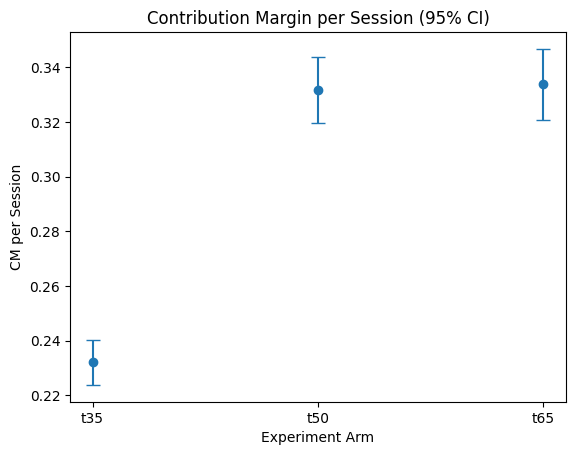

In [53]:
# confidence interval plots

plt.errorbar(
    cm_stats["threshold_arm"],
    cm_stats["mean_cm"],
    yerr=1.96 * cm_stats["standard_error"],
    fmt='o',
    capsize=5
)

plt.title("Contribution Margin per Session (95% CI)")
plt.xlabel("Experiment Arm")
plt.ylabel("CM per Session")

plt.show()

### 7.10 — Uncertainty Analysis

Confidence intervals were estimated for contribution margin per session.

The analysis shows:

    • `t35` performs significantly worse than the baseline  
    • `t50` and `t65` have very similar performance  
    • the estimated lift of `t65` over `t50` is extremely small

The confidence intervals for `t50` and `t65` overlap substantially, indicating that the observed difference is likely due to random variation.

Therefore, there is no strong statistical evidence that the $65 threshold improves contribution margin relative to the $50 baseline.  

---


## Step 8 — Apply the Decision Rule

### Goal

The purpose of this step is to combine the results of the experiment analysis and determine the final business recommendation.

The experiment was designed to evaluate which free shipping threshold maximizes contribution margin while maintaining healthy customer behavior and sustainable shipping economics.

The predefined decision framework was:

    1. The **primary metric (Contribution Margin per Session)** determines the winning treatment.
    2. **Secondary metrics** explain the behavioral mechanism.
    3. **Guardrail metrics** ensure the policy does not harm the business.
    4. **Uncertainty analysis** ensures the observed effects are reliable.

---

# 1. Primary Metric Result

Contribution margin per session:

| Arm | CM per Session |
|---|---|
| t35 | 0.232 |
| t50 | 0.332 |
| t65 | 0.334 |

Observations:

    - `t35` performs substantially worse than the baseline.
    - `t50` and `t65` perform nearly identically.
    - `t65` is slightly higher than `t50`, but the improvement is extremely small.

The observed difference between `t65` and `t50` is:

```
+0.002 CM per session
```

This represents a relative lift of approximately:

```
~0.6%
```

---

# 2. Secondary Metric Interpretation

Secondary metrics explain the behavioral mechanism behind the results.

| Arm | Conversion | AOV | Revenue / Session |
|---|---|---|---|
| t35 | highest | lowest | lowest |
| t50 | moderate | moderate | highest |
| t65 | lowest | highest | moderate |

Interpretation:

    - Lower thresholds increase conversion but reduce basket size.
    - Higher thresholds reduce conversion but increase basket size.
    - The $50 threshold produces the best balance of conversion and order value.

---

# 3. Guardrail Metrics

Guardrail metrics ensure the experiment does not introduce unacceptable risk.

| Arm | Shipping Subsidy | Negative Margin Orders |
|---|---|---|
| t35 | highest | 0% |
| t50 | moderate | 0% |
| t65 | lowest | 0% |

Interpretation:

    - Lower thresholds increase shipping subsidy exposure.
    - Higher thresholds reduce shipping costs but at the expense of conversion.
    - No treatment created negative margin orders.

---

# 4. Uncertainty Analysis

Confidence intervals and hypothesis tests indicate:

    - `t35` performs **significantly worse** than the baseline.
    - The difference between `t65` and `t50` is **not statistically significant**.

The confidence intervals for `t50` and `t65` overlap substantially.

This indicates that the observed difference between the two arms is likely due to random variation.

---

# Final Decision

Based on the experiment results, the recommended policy is:

```
Maintain the current $50 free shipping threshold.
```

Reasoning:

    1. The $35 threshold significantly harms profitability.
    2. The $65 threshold provides only a negligible improvement in margin.
    3. The $65 threshold reduces revenue per session and conversion.
    4. The difference between $50 and $65 is not statistically significant.

Therefore, there is insufficient evidence that changing the threshold would improve business outcomes.

---

# Key Takeaway

The experiment suggests that the current $50 threshold is already close to optimal.

The experiment does provide valuable insight by validating the current pricing and shipping strategy.  

---

### Visualization #1 Contribution Margin per Session by Threshold Arm

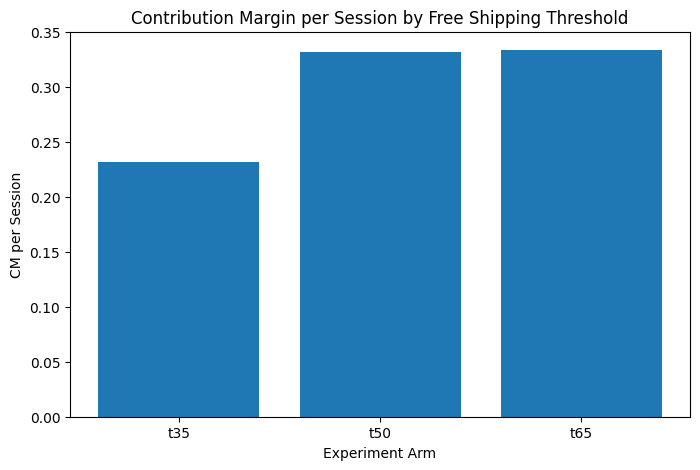

In [54]:
# contribution margin per session by fs threshold

primary_plot = summary.sort_values("threshold_arm")

plt.figure(figsize=(8,5))

plt.bar(
    primary_plot["threshold_arm"],
    primary_plot["cm_per_session"]
)

plt.title("Contribution Margin per Session by Free Shipping Threshold")
plt.xlabel("Experiment Arm")
plt.ylabel("CM per Session")

plt.show()

### Interpretation

This plot highlights the relative profitability of each threshold.

    - `$35` threshold produces significantly lower margin
    - `$50` and `$65` thresholds perform similarly
    - `$65` slightly exceeds `$50` but by a very small amount  

---

### Visualization 2 — Conversion vs Basket Size Tradeoff

This visualization illustrates the **core behavioral tradeoff** in the experiment.

Lower thresholds increase conversion but reduce basket size, while higher thresholds increase basket size but reduce conversion.

This chart helps explain the mechanism behind the experiment results.

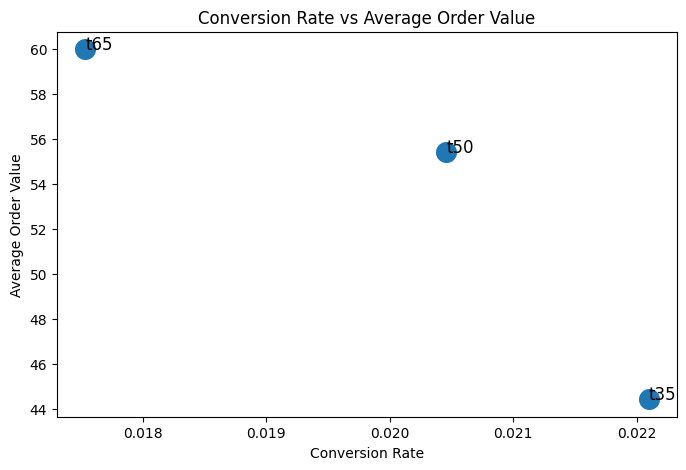

In [56]:
# conversion vs. basket size tradeoff

tradeoff_plot = summary.sort_values("threshold_arm")

plt.figure(figsize=(8,5))

plt.scatter(
    tradeoff_plot["conversion_rate"],
    tradeoff_plot["aov"],
    s=200
)

for i, row in tradeoff_plot.iterrows():
    plt.text(
        row["conversion_rate"],
        row["aov"],
        row["threshold_arm"],
        fontsize=12
    )

plt.title("Conversion Rate vs Average Order Value")
plt.xlabel("Conversion Rate")
plt.ylabel("Average Order Value")

plt.show()

### Interpretation

The plot should show:

- `t35` → high conversion, low AOV
- `t65` → low conversion, high AOV
- `t50` → balanced between the two

This visualizes the **conversion–basket size tradeoff** that drives free shipping threshold performance.  

---

### Visualization 3 — Contribution Margin Confidence Intervals

This chart visualizes the **uncertainty around the primary metric estimates**.

It shows the estimated contribution margin per session along with **95% confidence intervals**.


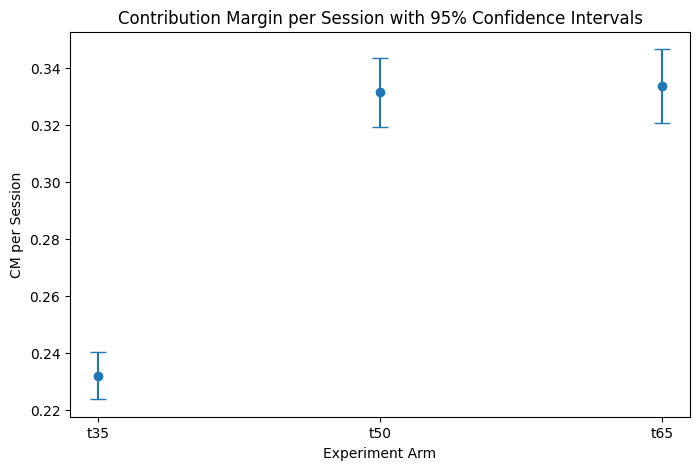

In [57]:
plt.figure(figsize=(8,5))

plt.errorbar(
    cm_stats["threshold_arm"],
    cm_stats["mean_cm"],
    yerr=1.96 * cm_stats["standard_error"],
    fmt='o',
    capsize=6
)

plt.title("Contribution Margin per Session with 95% Confidence Intervals")
plt.xlabel("Experiment Arm")
plt.ylabel("CM per Session")

plt.show()

### Interpretation

This chart helps answer a key experiment question:

> Are the observed differences likely real or just noise?

In this experiment, the confidence intervals for `t50` and `t65` overlap substantially, suggesting that the small observed difference is likely due to random variation rather than a meaningful improvement.  

---

## Final Experiment Results Table

This table summarizes the most important experiment metrics across treatment arms.

    - the primary metric
    - key behavioral metrics
    - important guardrail metrics

---

In [59]:
results_table = summary[[
    "threshold_arm",
    "conversion_rate",
    "aov",
    "revenue_per_session",
    "cm_per_session",
    "free_shipping_qualification_rate",
    "shipping_subsidy_per_order",
    "negative_margin_order_rate"
]].copy()



# format for readability
results_table_fmt = results_table.copy()

results_table_fmt["conversion_rate"] = (
    results_table_fmt["conversion_rate"] * 100
).round(2)

results_table_fmt["free_shipping_qualification_rate"] = (
    results_table_fmt["free_shipping_qualification_rate"] * 100
).round(2)

results_table_fmt["negative_margin_order_rate"] = (
    results_table_fmt["negative_margin_order_rate"] * 100
).round(2)

results_table_fmt["aov"] = results_table_fmt["aov"].round(2)
results_table_fmt["revenue_per_session"] = results_table_fmt["revenue_per_session"].round(3)
results_table_fmt["cm_per_session"] = results_table_fmt["cm_per_session"].round(3)
results_table_fmt["shipping_subsidy_per_order"] = results_table_fmt["shipping_subsidy_per_order"].round(2)

results_table_fmt

,threshold_arm,conversion_rate,aov,revenue_per_session,cm_per_session,free_shipping_qualification_rate,shipping_subsidy_per_order,negative_margin_order_rate
0,t35,2.21,44.44,1.020,0.232,71.39,7.28,0.0
1,t50,2.05,55.40,1.196,0.332,49.30,5.95,0.0
2,t65,1.75,59.99,1.122,0.334,32.79,4.96,0.0


# Estimating Annual Business Impact

We estimate the potential annual impact by multiplying the difference in contribution margin per session by the estimated number of sessions per year.

---

### Assumptions

Average traffic:

    10,000 sessions per day

Estimated annual traffic:

    10,000 × 365 = 3,650,000 sessions per year

Baseline threshold:

    t50

---

In [60]:
sessions_per_day = 10000
annual_sessions = sessions_per_day * 365

baseline_cm = summary.loc[
    summary["threshold_arm"] == "t50",
    "cm_per_session"
].iloc[0]

impact_table = summary[["threshold_arm", "cm_per_session"]].copy()

impact_table["cm_lift_vs_t50"] = (
    impact_table["cm_per_session"] - baseline_cm
)

impact_table["annual_impact"] = (
    impact_table["cm_lift_vs_t50"] * annual_sessions
)

impact_table

,threshold_arm,cm_per_session,cm_lift_vs_t50,annual_impact
0,t35,0.231978,-0.099621,-363614.828528
1,t50,0.331599,0.000000,0.000000
2,t65,0.333675,0.002077,7579.422832


## Key Insight  

Although the $65 threshold slightly improves contribution margin per session, its total annual impact of $7,500 is very small relative to overall revenue.  


This also highlights how harmful the $35 threshold would have been with a total annual impact of -$360,000. 


_This reinforces the conclusion that changing the threshold would likely not produce meaningful business improvement._

---  